# 01 — Initial exploration

**Mock data only.** This notebook is for building/testing the pipeline
(DB → pandas → plots), not for drawing conclusions about vehicle
behavior — any correlations here are artifacts of the mock generator,
not real signal. Swapping in real data later should require no changes
below, just new rows underneath.

In [1]:
import sys, os

# diagnostic — confirm kernel/env are what we expect before doing anything else
print("Python executable:", sys.executable)
print("PYTHONPATH env var:", repr(os.environ.get("PYTHONPATH")))
print("ROS-looking paths in sys.path:", [p for p in sys.path if "ros" in p.lower()] or "none")

Python executable: /home/buvindu-suraweera/vehicle-telemetry-platform/analytics/.venv/bin/python
PYTHONPATH env var: ''
ROS-looking paths in sys.path: none


In [5]:
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.db import query

sns.set_theme(style="darkgrid")

## Connection check

In [6]:
sessions = query("SELECT * FROM sessions ORDER BY started_at;")
sessions

/home/buvindu-suraweera/vehicle-telemetry-platform/analytics/src/db.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


,id,driver_id,started_at,ended_at,notes
0,mock_001,driver_a,2026-07-14 13:55:47.463213+00:00,None,Mock data session
1,live_001,driver_a,2026-07-14 13:55:47.466473+00:00,None,Live OBD session


## Pull raw telemetry

Adjust `session_id` below to whichever session the migrated mock data
actually landed under.

In [7]:
SESSION_ID = "mock_001"

df = query(
    "SELECT * FROM telemetry WHERE session_id = %(session_id)s ORDER BY time;",
    params={"session_id": SESSION_ID},
)
print(df.shape)
df.head()

(12557, 12)


/home/buvindu-suraweera/vehicle-telemetry-platform/analytics/src/db.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


,time,session_id,speed_kmh,rpm,throttle_pct,coolant_temp_c,engine_load_pct,accel_x,accel_y,accel_z,latitude,longitude
0,2026-06-24 16:16:48.035467+00:00,mock_001,65.4,3623.0,43.9,83.4,35.1,NaN,NaN,NaN,None,None
1,2026-06-24 16:16:48.035518+00:00,mock_001,NaN,NaN,NaN,NaN,NaN,-0.027,0.116,9.785,None,None
2,2026-06-24 16:16:48.136384+00:00,mock_001,65.5,3597.0,42.9,85.0,34.3,NaN,NaN,NaN,None,None
3,2026-06-24 16:16:48.136415+00:00,mock_001,NaN,NaN,NaN,NaN,NaN,0.023,-0.030,9.743,None,None
4,2026-06-24 16:16:48.236922+00:00,mock_001,65.7,3553.0,43.3,85.3,34.7,NaN,NaN,NaN,None,None


In [8]:
df.describe()

,speed_kmh,rpm,throttle_pct,coolant_temp_c,engine_load_pct,accel_x,accel_y,accel_z
count,10343.000000,10343.000000,10343.000000,10343.000000,10343.000000,10343.000000,10343.000000,10343.000000
mean,59.218554,3368.767669,41.307599,84.995388,33.046582,-0.001725,-0.000201,9.810286
std,21.480879,859.655932,14.486496,0.984869,11.588952,0.298500,0.099248,0.049839
min,30.000000,2042.000000,8.900000,81.400000,7.100000,-1.219000,-0.378000,9.616000
25%,37.300000,2498.500000,27.500000,84.300000,22.000000,-0.207000,-0.067000,9.777000
50%,58.800000,3349.000000,42.700000,85.000000,34.100000,-0.003000,0.001000,9.811000
75%,80.650000,4228.000000,54.900000,85.600000,43.900000,0.202000,0.067000,9.844000
max,90.000000,4765.000000,69.200000,88.800000,55.300000,1.094000,0.385000,9.975000


## First-look plots

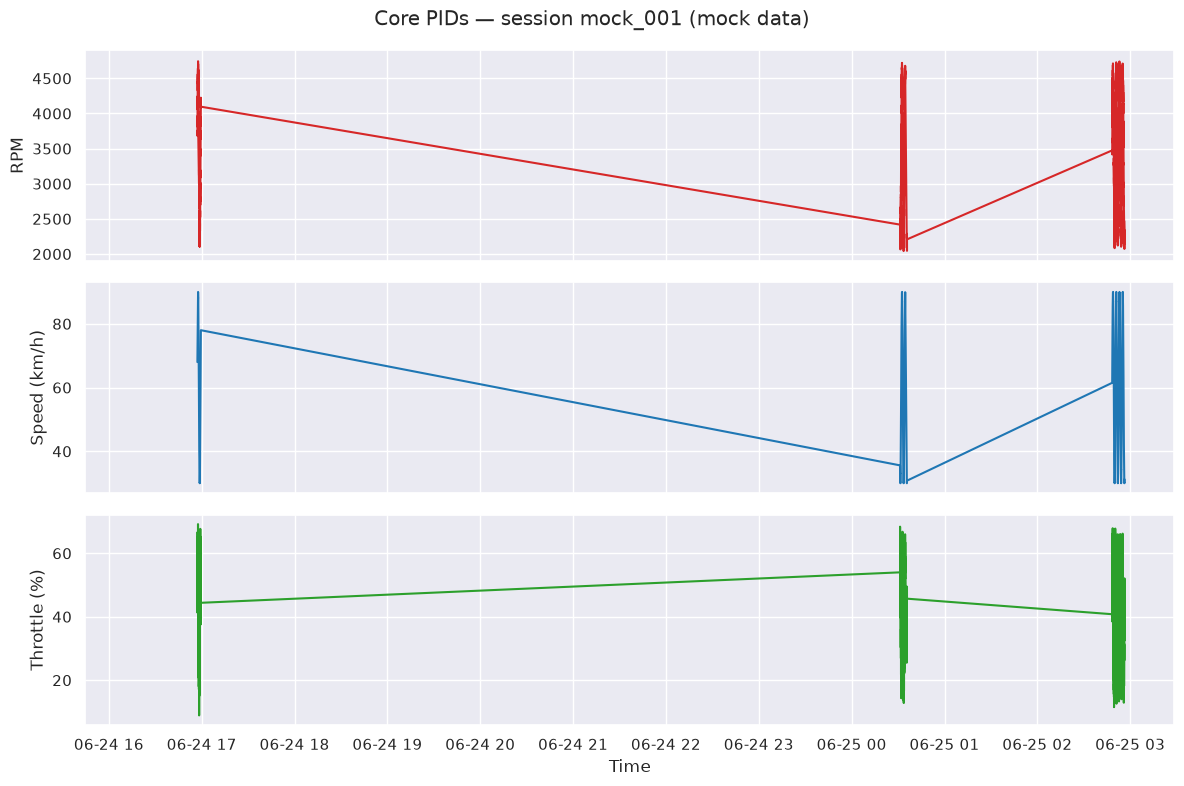

In [9]:
# Core PIDs over time — sanity check that the shapes look sane, not an
# analysis conclusion
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df["time"], df["rpm"], color="tab:red")
axes[0].set_ylabel("RPM")

axes[1].plot(df["time"], df["speed_kmh"], color="tab:blue")
axes[1].set_ylabel("Speed (km/h)")

axes[2].plot(df["time"], df["throttle_pct"], color="tab:green")
axes[2].set_ylabel("Throttle (%)")
axes[2].set_xlabel("Time")

fig.suptitle(f"Core PIDs — session {SESSION_ID} (mock data)")
fig.tight_layout()

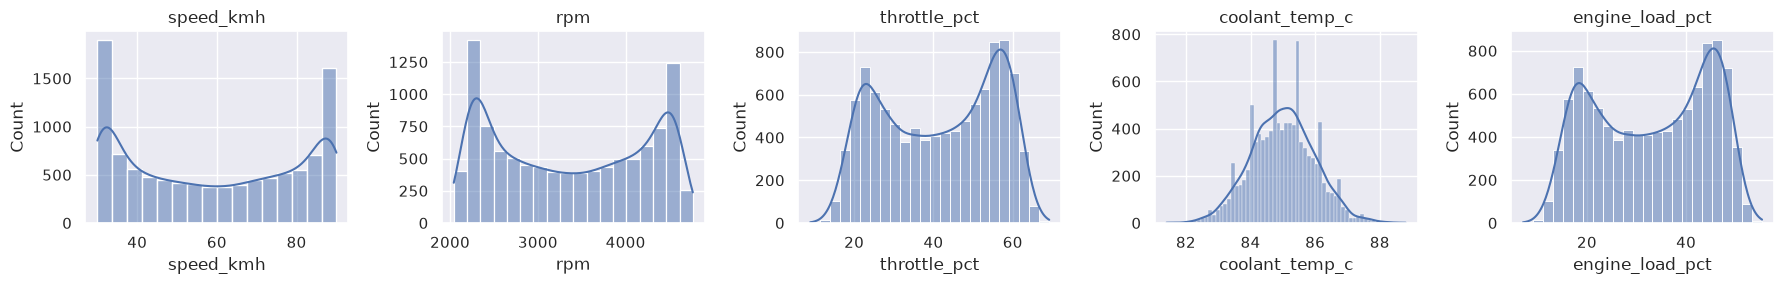

In [10]:
# Distributions — quick shape check across all core PIDs
core_pids = ["speed_kmh", "rpm", "throttle_pct", "coolant_temp_c", "engine_load_pct"]

fig, axes = plt.subplots(1, len(core_pids), figsize=(18, 3))
for ax, col in zip(axes, core_pids):
    sns.histplot(df[col].dropna(), ax=ax, kde=True)
    ax.set_title(col)
fig.tight_layout()

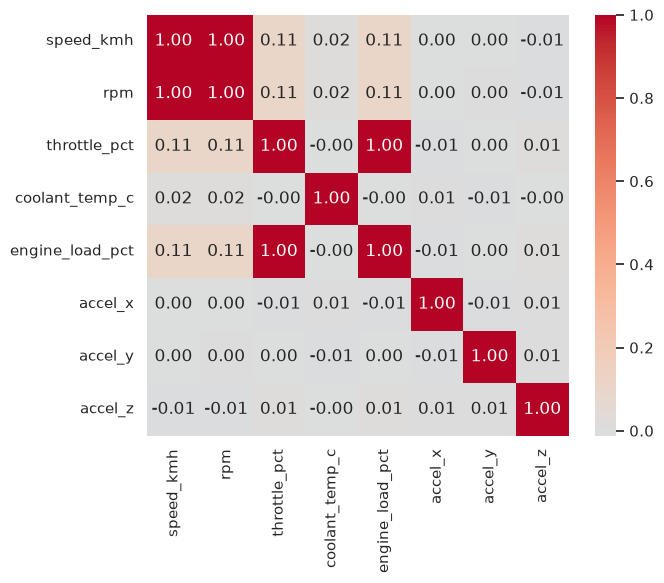

In [11]:
# Correlation matrix — pipeline check only. Do NOT read anything into
# these values while the data is synthetic — correlations here reflect
# the mock generator's own logic, not vehicle behavior.
corr = df[core_pids + ["accel_x", "accel_y", "accel_z"]].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
fig.tight_layout()